# 수업 내용
1. 랭체인 기본코드 복습
2. Gradio UI 사용 방법 이해
3. 랭체인 + Gradio UI
4. UI 꾸미는 방법 소개
5. [미션] 나만의 RAG 시스템 만들기


# 1. 랭체인 기본코드 복습
- Gradio 수업 전, 간단히 랭체인을 복습합니다.

### 랭체인을 돌리기 위한 준비

In [ ]:
%%capture
!pip install langchain langchain-openai
!pip install --upgrade langchain # 랭체인 공식 버전으로 설치됩니다

import os, sys
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("OPEN_AI")

### 랭체인 Agent 기본 코드 실행
- 아래 코드는 공식문서의 기본 코드입니다.
  - 날씨를 알려주는 Tool이 존재합니다.
  - Model이 툴을 사용해야한다고 판단하면, 툴을 사용합니다.
- 코드 출처 : https://docs.langchain.com/oss/python/langchain/quickstart

In [ ]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """city의 날씨를 알려주는 도구"""
    return "허리케인"

agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[get_weather],
    system_prompt="""
      넌 아주 친절한 AI 도구야, 아이처럼 말해
      사용자가 요청하면 필요한 도구를 한번 만 사용해
      넌 get_weather(city)라는 도구를 가지고 있고, 원하는 city의 날씨를 반환해주는 도구지
    """
)

# Run the agent
result = agent.invoke(
    {"messages": [{"role": "user", "content": "오늘 서울 날씨가 궁금해"}]}
)

answer = result["messages"][-1].content
print(answer)

오늘 서울 날씨는 허리케인이에요! 바람이 많이 불고 비도 올 것 같아요. 밖에 나가기 전에 잘 준비하세요!


# 2. Gradio UI 소개

### Gradio 소개
- Python 기반 머신러싱 모델의 **데모 App**을 만들기 위한 오픈소스 패키지 입니다.
  - **몇 초만에 Web Application의 URL을 생성할 수 있습니다.**
  - 코랩에 내장되어있습니다. 별도 설치가 필요하지 않습니다.

- 아래이미지는 gradio UI 동작 예시입니다.
  - 이미지 출처 : https://www.gradio.app/guides/quickstart

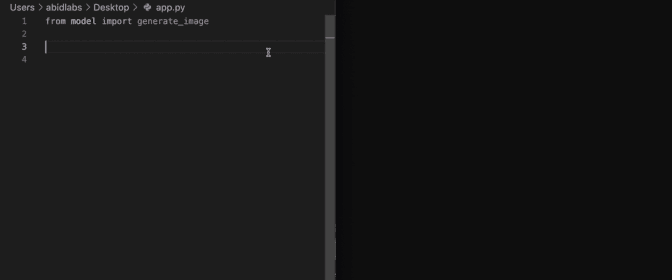

### Gradio 기본코드

- 기본 코드를 실행하기 전에, 아래 코드를 실행해주세요.
  - 코랩에서 재실행 속도를 높혀주는 확장도구입니다.

In [ ]:
# ===============================================================================
# 다음은 코랩에서 Reload 속도를 올리는 확장기능을 사용하는 명령어입니다.
%load_ext gradio
# ===============================================================================

- 아래는 Gradio 공식 Hello world 코드입니다.
- 강도 스크롤을 높일수록 "!" 가 늘어납니다.
  - 코드 출처 : https://www.gradio.app/guides/quickstart#building-your-first-demo

- URL도 나오는데, 1주일간 무료라고 합니다.
  - 한번 클릭해보세요.

In [ ]:
import gradio as gr

def greet(name, intensity):
    return "Hello, " + name + "!" * int(intensity)

demo = gr.Interface(
    fn=greet,
    inputs=["text", "slider"],
    outputs=["text"],
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ed2ad252f6a1e999be.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 3. 랭체인과 Gradio 연동
- 자! 이제 랭체인 기본코드와 Gardio를 연동해봅시다.

### 랭체인 + Gardio 대화창 코드
- 랭체인의 invoke 함수를 chat 함수에 넣으면 끝입니다.
- 아래 코드를 실행하기 위해서, 교안 상단의 코드를 실행해야합니다.

In [ ]:
import gradio as gr

def chat(message, history):
    result = agent.invoke({"messages": [{"role": "user", "content": message}]})
    answer = result["messages"][-1].content

    history = history + [
        {"role": "user", "content": message},
        {"role": "assistant", "content": answer}
    ]
    return "", history

# ========================================
# Gradio Blocks 기반 UI
# ========================================
with gr.Blocks(title="LangChain Agent Chat") as demo:
    gr.Markdown("## 🤖 LangChain Agent Chat\nLangChain Agent가 도구를 활용해 답변합니다.")

    chatbot = gr.Chatbot(
        height=280,
        label="대화창",
        type="messages"
    )

    msg = gr.Textbox(
        label="💬 질문을 입력하세요",
        placeholder="예: 오늘 서울 날씨 어때?",
    )

    # 엔터 누르면 chat 함수 호출
    msg.submit(chat, inputs=[msg, chatbot], outputs=[msg, chatbot])

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1d3ac6bb90fd7db41b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 4. Gradio UI를 Vibe 코딩으로 꾸미기
- 손쉽게 UI를 꾸며봅시다.
- 먼저 아래 코드를 실행해서 app.py 파일로 저장합니다.

In [ ]:
# ========================================================
# 다음은 소스코드를 ./app.py 파일로 저장하는 명령어입니다.
%%writefile app.py
# ========================================================
import gradio as gr

def chat(message, history):
    result = agent.invoke({"messages": [{"role": "user", "content": message}]})
    answer = result["messages"][-1].content

    history = history + [
        {"role": "user", "content": message},
        {"role": "assistant", "content": answer}
    ]
    return "", history

# ========================================
# Gradio Blocks 기반 UI
# ========================================
with gr.Blocks(title="LangChain Agent Chat") as demo:
    gr.Markdown("## 🤖 LangChain Agent Chat\nLangChain Agent가 도구를 활용해 답변합니다.")

    chatbot = gr.Chatbot(
        height=300,
        label="대화창",
        type="messages"
    )

    msg = gr.Textbox(
        label="💬 질문을 입력하세요",
        placeholder="예: 오늘 서울 날씨 어때?",
    )

    # 엔터 누르면 chat 함수 호출
    msg.submit(chat, inputs=[msg, chatbot], outputs=[msg, chatbot])

demo.launch(share=True)


Overwriting app.py


In [ ]:
# ========================================================
# 다음은 소스코드를 ./app.py 파일로 저장하는 명령어입니다.
%%writefile app.py
# ========================================================
# app.py
# ========================================
# Gradio + LangChain RAG (Chroma + Upstage)
# - RAG 준비되면 rag_chain 사용
# - RAG 실패/미준비 시 OpenAI LLM(ChatOpenAI)로 폴백
# ========================================

import os
import gradio as gr

# ---------- RAG 준비 (Chroma + Upstage) ----------
from langchain_community.vectorstores import Chroma
from langchain_community.document_loaders.text import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_upstage import UpstageEmbeddings, ChatUpstage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# ---------- OpenAI 폴백 ----------
from langchain_openai import ChatOpenAI  # << 에이전트 대신 단순 LLM 폴백

PERSIST_DIR = "./chroma_store"
DATA_FILE = "./zeyook.txt"  # 없으면 인덱스 생성 패스

def _require_api_key() -> str:
    key = os.getenv("UPSTAGE_API_KEY")
    if not key:
        raise RuntimeError("환경변수 UPSTAGE_API_KEY 가 설정되지 않았습니다.")
    return key

def build_or_load_vectorstore() -> Chroma:
    key = _require_api_key()
    embeddings = UpstageEmbeddings(model="embedding-query", api_key=key)

    # 이미 생성된 인덱스가 있으면 로드
    if os.path.isdir(PERSIST_DIR) and os.listdir(PERSIST_DIR):
        return Chroma(embedding_function=embeddings, persist_directory=PERSIST_DIR)

    # 없으면 데이터 파일로부터 생성
    if os.path.exists(DATA_FILE):
        loader = TextLoader(DATA_FILE, encoding="utf-8")
        docs = loader.load()
        splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=40)
        chunks = splitter.split_documents(docs)
        vs = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=PERSIST_DIR)
        vs.persist()
        return vs

    raise RuntimeError(
        f"벡터 인덱스가 없습니다. {PERSIST_DIR} 를 준비하거나, {DATA_FILE} 를 만들어 주세요."
    )

def format_docs(docs):
    # retriever가 반환하는 List[Document] -> 프롬프트에 넣을 문자열
    formatted = []
    for i, d in enumerate(docs, 1):
        formatted.append(f"[출처 {i}]\n{d.page_content}")
    return "\n\n".join(formatted)

def build_rag_chain(k: int = 8):
    key = _require_api_key()
    vector_store = build_or_load_vectorstore()
    retriever = vector_store.as_retriever(search_kwargs={"k": k})

    llm = ChatUpstage(model="solar-pro2", api_key=key)

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "너는 검색된 컨텍스트 내용만을 사용해서 답해야 해. "
         "컨텍스트에 없는 정보는 절대 만들어내지 마. "
         "정답이 없으면 '문서에 양념 만드는 방법이 없습니다.'라고 말해."),
        ("user",
         "다음은 문서에서 검색된 컨텍스트야. 반드시 이 내용 안에서만 답을 해.\n\n"
         "[질문]: {question}\n\n[컨텍스트]:\n{context}")
    ])

    setup = RunnableParallel(
        context=retriever | format_docs,
        question=RunnablePassthrough()
    )

    return setup | prompt | llm | StrOutputParser()

# 전역으로 한 번만 준비 (RAG 체인)
try:
    rag_chain = build_rag_chain(k=4)
    RAG_READY = True
    RAG_ERROR = ""
except Exception as e:
    RAG_READY = False
    RAG_ERROR = str(e)

# ---------- OpenAI LLM 폴백 ----------
# OPENAI_API_KEY 가 환경변수로 있어야 합니다.
def build_openai_fallback():
    try:
        return ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
    except Exception:
        return None

openai_llm = build_openai_fallback()

# ---------- Gradio UI ----------
def chat(message, history):
    # 1) RAG가 준비되었으면 RAG 우선
    if RAG_READY:
        try:
            answer = rag_chain.invoke(message)
        except Exception as e:
            # RAG 실행 중 오류 → OpenAI LLM 폴백
            if openai_llm:
                try:
                    answer = openai_llm.invoke(message).content
                except Exception as e2:
                    answer = f"❌ RAG 오류: {e}\n❌ OpenAI 오류: {e2}"
            else:
                answer = f"❌ RAG 오류: {e}\n❌ OpenAI 미준비: OPENAI_API_KEY를 확인하세요."
    else:
        # 2) RAG 미준비 → 바로 OpenAI LLM 폴백
        if openai_llm:
            try:
                answer = openai_llm.invoke(message).content
            except Exception as e:
                answer = f"❌ OpenAI 오류: {e}"
        else:
            answer = f"❌ RAG 미준비: {RAG_ERROR}\n❌ OpenAI 미준비: OPENAI_API_KEY를 확인하세요."

    history = history + [
        {"role": "user", "content": message},
        {"role": "assistant", "content": answer}
    ]
    return "", history

with gr.Blocks(title="RAG Chat (Chroma + Upstage) — Fallback to OpenAI LLM") as demo:
    gr.Markdown(
        "## 🍖 제육볶음 RAG 데모 (자동 폴백)\n"
        "- 가능하면 **RAG(Chroma + Upstage)**로 답하고, 실패시 **OpenAI LLM**으로 폴백합니다.\n"
        "- 인덱스가 없으면 `zeyook.txt`로 자동 생성합니다(파일이 있을 때만)."
    )

    if not RAG_READY:
        gr.Markdown(f"**현재 상태:** RAG 준비 실패 → {RAG_ERROR}")

    chatbot = gr.Chatbot(height=360, label="대화창", type="messages")
    msg = gr.Textbox(label="💬 질문을 입력하세요", placeholder="예: 양념은 어떻게 만들지?")

    msg.submit(chat, inputs=[msg, chatbot], outputs=[msg, chatbot])

demo.launch(share=True)


Overwriting app.py


### Gradio - Vibe Mode
- Gradio UI를 꾸밀때 참고해야할 기능입니다.
  - **공식 Documentation**
    - Documentation에는 기능별로 샘플코드가 준비되어 있습니다.
    - https://www.gradio.app/docs/gradio/introduction
    
  - **Playground**
    - 에서 자유롭게 UI를 테스트 해볼 수 있지만, 곧 삭제(Deprecated) 될 예정입니다.
    - Deprecated 되고, 다른 것으로 업데이트가 될것 같습니다.
    - 일단은 유용하기 때문에, 사라지기 전까지 사용하시면 됩니다.
    - https://www.gradio.app/playground
    
  - **UI 바이브 코딩**
    - 공식 Documentaion 대신 UI를 바이브 코딩으로 꾸밀 수 있습니다.
    - 이 기능은 허깅페이스의 추론용 API를 사용합니다.
    - 이를 위해 허깅페이스의 API Key를 발급 받습니다.

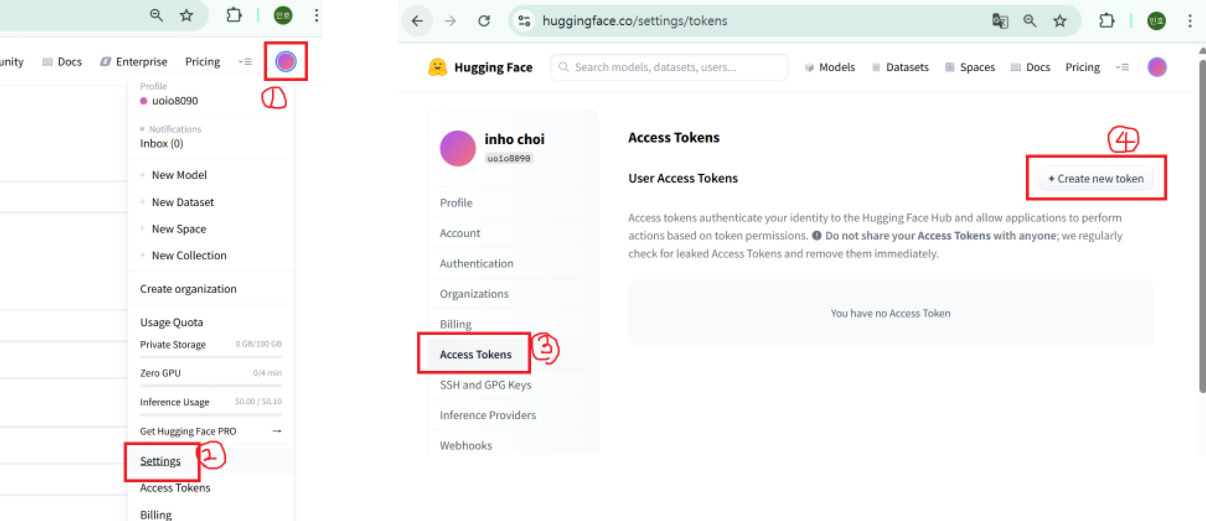

- Read 권한으로 간단한 토큰을 생성합니다.

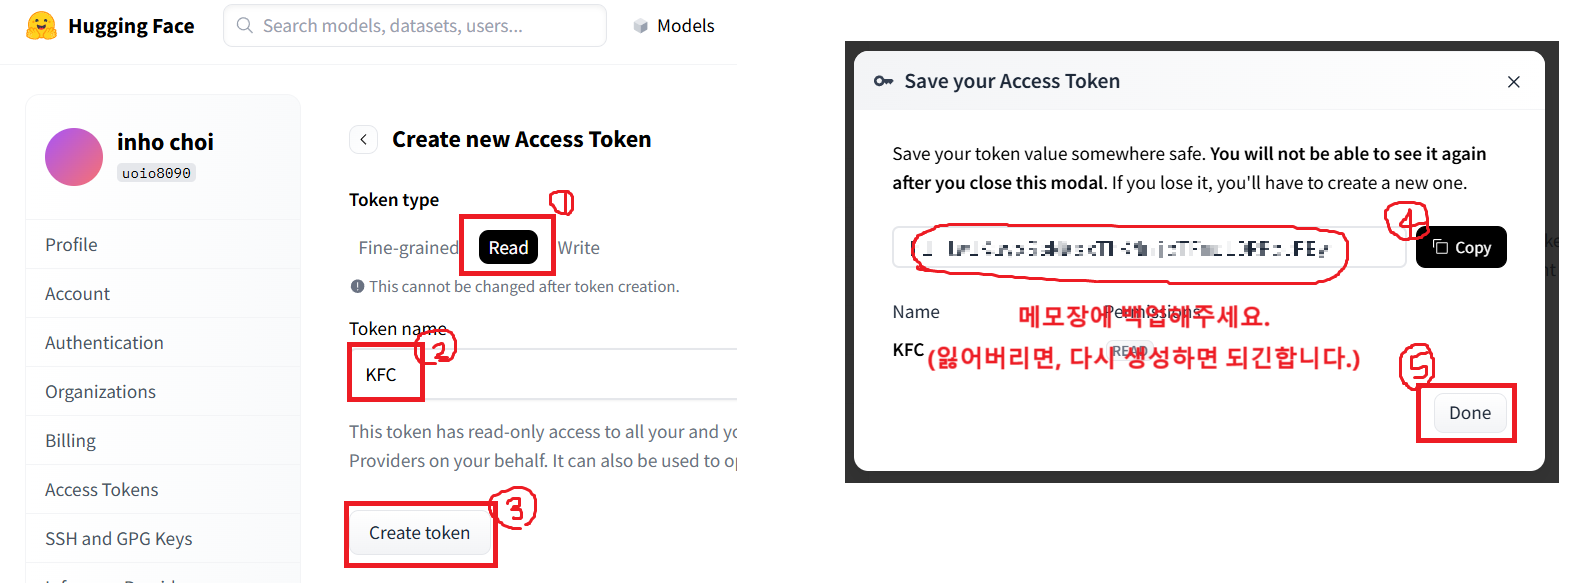

- 메모장 대신, 키를 열쇠버튼을 누르고 **HF_TOKEN** 이라는 이름으로 키를 등록
  - 백업용으로 사용하면 편리합니다. ^^;

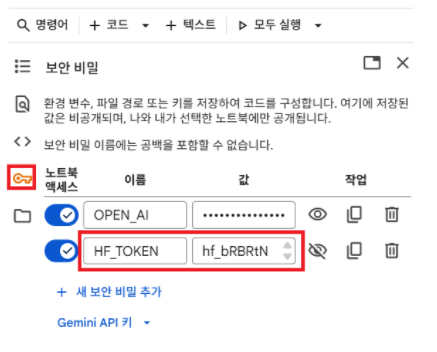

- 아까 예제를 app.py로 저장해두었습니다.
  - 이 코드를 gradio --vide 옵션으로 실행하면 됩니다.

- 아래 코드를 실행합니다.
  - Enter your token : **허깅페이스 키 입력**
  - Add token as git credential? (허깅페이스의 Git도 사용할텐가?) : **n 입력**
  - Stay logged in to Hugging Face? (로그인 유지할텐가?) : **Y 입력**

- 이후 URL이 나오면 클릭합니다.

In [ ]:
!gradio --vibe app.py


⚠️  WARNING: Vibe editor mode is enabled. Anyone who can access the Gradio endpoint can modify files and run arbitrary code on the host machine. Use with caution!

🔓  Logged in to Hugging Face as sanghojang. You can logout at any time with: hf auth logout

Watching: '/content'

* Running on local URL:  http://127.0.0.1:7864
* Running on public URL: https://9c83087ec3cd77f0aa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Changes detected in: /content/app.py
Changes detected in: /content/app.py
Keyboard interruption in main thread... closing server.
Exception ignored in atexit callback: <bound method finalize._exitfunc of <class 'weakref.finalize'>>
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 666, in _exitfunc
    f()
  File "/usr/lib/python3.12/weakref.py", line 590, in __call_

- 실행결과는 다음과 같습니다.
- 프롬프트를 입력하여 꾸며주세요.
  - 예시
    - TextBox 하나 더 추가해봐
    - 대화창 크기를 줄여줘

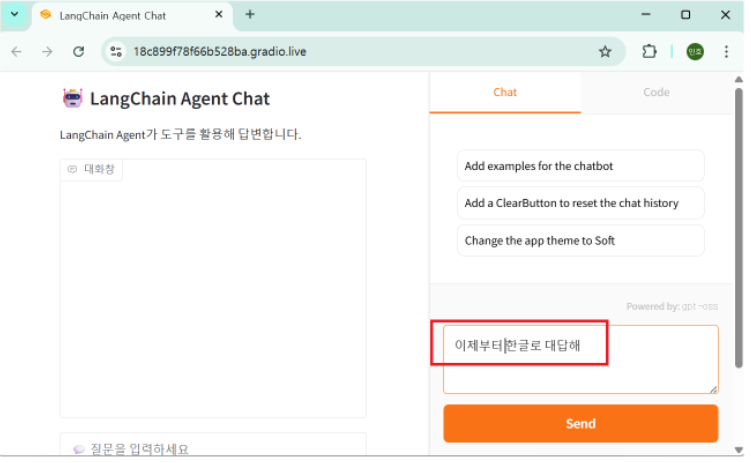



- 완성 후 [Code] 탭에서 [Update Code]를 저장하면 app.py 내용이 업데이트 되어있습니다.

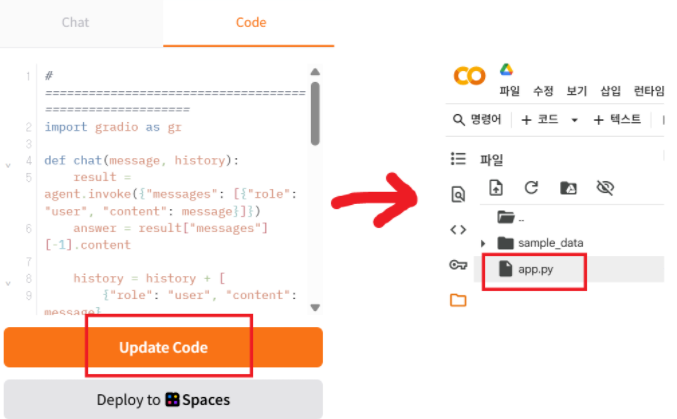

- app.py 코드를 보면서, 나만의 UI를 꾸밀 수 있습니다.
- 이 Vibe 모드를 켜두고, 동시에 PlayGound (사라질 예정) 또는 Document를 보면서 개발하면 나만의 UI를 완성할 수 있습니다.
  - PlayGround : https://www.gradio.app/playground
  - Document : https://www.gradio.app/guides/creating-a-custom-chatbot-with-blocks


# 5. [미션] 나만의 RAG 시스템 만들기
- 나만의 RAG 시스템을 만드는 미션입니다.
- 기존 실습자료를 참고하여, RAG 시스템을 만들어주세요!

In [ ]:
!pip install langchain-upstage langchain_community chromadb

In [ ]:
from langchain_upstage import UpstageEmbeddings
import os, getpass

os.environ["UPSTAGE_API_KEY"] = getpass.getpass("여기에 UpStage API 키를 입력하시오: ")
print('환경변수에 UpStage API키를 등록하였습니다.')

# API KEY가 올바른지 테스트 코드
ret = UpstageEmbeddings(model="embedding-query", api_key=os.environ["UPSTAGE_API_KEY"]).embed_documents("TEST")

KeyboardInterrupt: Interrupted by user

### 미션 1 - 데이터 준비하기

- 교육생 여러분은 먼저 어떤 내용을 RAG로 만들지 정해야합니다.
- 데이터를 검색하여 Text 파일을 준비해주세요.
- 유의사항
  - RAG를 수행하기 전, 모델이 못하는 정보를 사용해야합니다.
  - 직접 테스트하는 코드를 추가하여, 수집할 정보가 모델이 알고있는지 테스트해주세요.

In [ ]:
# 예시로 사용할 '제육볶음 레시피' 문서를 만듭니다.
%%writefile zeyook.txt

========================
1. 재료 손질
========================
[채소]
대파는 길이감 있게 대략 4~5cm 길이로 잘라준다.
당근도 비슷한 길이로 편썰어준다.
양배추는 먹기 좋게 자른다.
양파는 채썰어 준비한다.

[고기]
고기는 불고깃감으로 얄팍하게 썰어진걸 구입한다.
키친타월로 눌러 겉면을 닦는다.

==============
2. 양념 만들기
==============
고추장 2 큰 술
진간장 3 큰 술
다진 마늘 1.5 큰 술
물 120ml
고루 섞어주고, 진간장 대신 양조간장 사용해도 상관없다.
설탕, 고춧가루는 따로 넣을 거라 각각 준비해 둔다.

==============
3. 볶기
==============
팬에 식용유 2 큰 술 정도를 두르고 대파 흰 대부분을 넣어 볶는다.
이후 고기를 넣어 완전히 익도록 볶아준다.

==============
4. 양념 넣기
==============
고기가 익으면 설탕 2 큰 술을 넣어 고루 볶아준다.
입자가 큰 설탕을 먼저 넣어주면 간이 더 균형있게 잘 배어든다.
국물이 절반 정도 줄고 배어들게 한다.

==============
5. 채소 넣기
==============
양배추, 당근, 양파, 대파 파란 대를 넣어 뒤적여 국물이 촉촉하게 남아 있는 상태까지 익혀준다.

==============
6. 고춧가루, 고추 넣기
==============
고춧가루는 마른 상태라 수분을 많이 빨아들이면서 불게 된다.
마지막에 넣어서 남은 국물을 흡수하면서 농도를 조절하게 해준다.
국물이 너무 적게 남아 있으면 뻑뻑해질 수 있다.
촉촉한 상태로 남아 있을 때 넣어주는데 만약 넣어서 섞다가 너무 빡빡하다 하면 물을 약간 보충해서 촉촉하게 해준다.
고루 잘 섞어 볶다가 청, 홍고추를 넣어 준다.

==============
7. 완성
==============
통깨 1 큰술, 참기름 1 큰 술 넣고 후춧가루 톡톡톡 넣어서 고루 섞어 마무리한다.

### 미션 2 - 청킹 후, Vector DB에 임베딩 벡터값 저장하기
- 교육생 여러분은 준비하신 Text파일을 청킹, 임베딩 하여 Vector DB에 저장해야합니다.


In [ ]:
from langchain_community.document_loaders.text import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 1. Load: 텍스트 파일 불러오기
loader = TextLoader("./zeyook.txt", encoding="utf-8")
documents = loader.load()
print("--- 원본 문서 ---")
print(documents[0].page_content)

# 2. Split: 문서를 200자 단위로 자르기 (엔터 단위, 40자씩 겹치게)
# 시험에 나옴.
# chunk 하는 이유 : RAG하는데 용이하게 하기 위해
# chunk_size=200, chunk_overlap=40
text_splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=40)
chunks = text_splitter.split_documents(documents)


print("\n--- 200자 단위로 잘린 문서 조각(Chunk)들 ---")
for i, chunk in enumerate(chunks):
    print(f"[Chunk {i+1}]")
    print(chunk.page_content)
    print()
    print()

In [ ]:
from langchain_community.vectorstores import Chroma
from langchain_upstage import UpstageEmbeddings

# 텍스트를 숫자 벡터로 변환해주는 '임베딩 모델'을 준비합니다.
embeddings = UpstageEmbeddings(model="embedding-query", api_key=os.environ["UPSTAGE_API_KEY"])

# 잘라낸 문서 조각(chunks)들을 임베딩하여 Vector DB에 저장합니다.
vector_store = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory="./chroma_store")

print("Chunk들을 Vector DB에 저장 완료")

### 미션3 - RAG 구현하기
 - LangChain을 이용하여 RAG를 구현합니다.
 - 이전에 수업했던 코드를 참고하여 완성합니다.

In [ ]:
retriever = vector_store.as_retriever()

question = "양념은 어떻게 만들지?"

# retriever.invoke(질문) 을 실행하면, 질문과 가장 관련 높은 문서 조각을 찾아줍니다.
# question을 임베딩벡터로 변환 후 검색을 시작합니다.
retrieved_docs = retriever.invoke(question)

print(f"[질문]: {question}")
print(f"\n[검색 결과]:\n{retrieved_docs[0].page_content}")

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_upstage import ChatUpstage

# LLM 모델을 준비합니다.
llm = ChatUpstage(model="solar-pro2", api_key=os.environ["UPSTAGE_API_KEY"])

# LLM에게 어떤 역할을 할지 알려주는 프롬프트(지시서)를 만듭니다.
prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 AI 온라인 서점의 친절한 고객 서비스 담당자입니다. 주어진 정보를 바탕으로 사용자의 질문에 답변해주세요."),
    ("user", "[질문]: {question}\n\n[참고 정보]: {context}"),
])

# RAG 체인(Chain)을 만듭니다.
rag_chain = (
    {
      "context": retriever, # 컴포넌트 1 : 전달받은 입력값(question_input1, 2)을 vector db에 검색 후 검색결과를 반환
      "question": RunnablePassthrough(),    # 컴포넌트 2 : 전달받은 입력값(question_input1, 2)을 그대로 반환
    }
    | prompt                # 컴포넌트 3 : {context, question} 딕셔너리가 입력되면, 완성된 프롬프트를 반환
    | llm                   # 컴포넌트 4 : 완성된 프롬프트를 LLM에 전달, 완성된 프롬프트를 반환
    | StrOutputParser()     # 컴포넌트 5. LLM이 반환한 정보 중, Text 답변만 문자열로 반환
)

print("RAG 체인 준비 완료!")
print("----------------------------")
print()
print()

# RAG 체인에 질문을 던져봅니다.
question_input1 = "양념알려줘"
answer1 = rag_chain.invoke(question_input1)
print(f"[질문 1]: {question_input1}")
print(f"[답변 1]: {answer1}")

print()
print()
print("----------------------------")
print()
print()

question_input2 = "손질은 어떻게해?"
answer2 = rag_chain.invoke(question_input2)
print(f"[질문 2]: {question_input2}")
print(f"[답변 2]: {answer2}")

### 미션 4 - Gradio UI와 연동하기
- 이제 멋지게 화면을 구성할 차례입니다.
- Web Application을 제작해주세요.
- 이후에 Vibe 코딩으로 독창적이고 멋진 UI를 완성해주세요.

### 미션 5 - Mattermost로 URL 제출하기
- 멋지게 만든 작품의 URL을 각반의 MM에 올려주세요.

# 6. 끝으로
- Gradio UI는 몇 초만에 GUI를 구성할 수 있는 패키지입니다.
- 이번 수업으로 나만의 RAG 시스템을 만들어보고, Web App Demo까지 만들어 보았습니다.
- 다음 수업에는 나만의 파인튜닝한 모델을 만들어보고, RAG와 비교를 해보는 시간을 갖겠습니다.

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.